In [2]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import pathlib
from sklearn.model_selection import StratifiedKFold
import shap
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error
from matplotlib import font_manager, rcParams

# 设置中文字体（可选）
font_path = "../wqy-zenhei.ttc"
font_manager.fontManager.addfont(font_path)
font_prop = font_manager.FontProperties(fname=font_path)
rcParams['font.sans-serif'] = [font_prop.get_name()]
rcParams['axes.unicode_minus'] = False

0.0 1.0


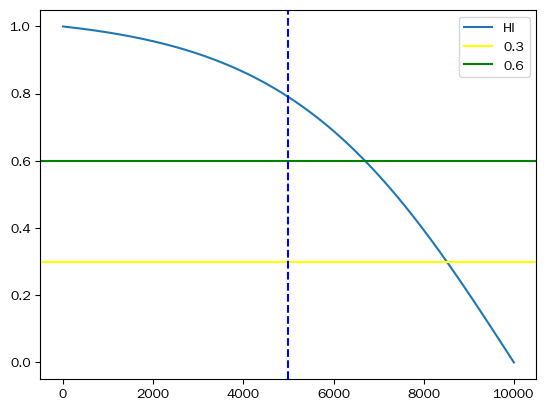

In [3]:
total_life = 10000
label = np.linspace(1, 0, num=total_life) # 假设已经有了一个全生命周期的csv文件，一共1000行
steepness = 4 # 越小越平滑，那接下来就是如何找到最适合设备的steepness
s_label = 1 / (1 + np.exp(-steepness * label))
s_label = (s_label - s_label.min()) / (s_label.max() - s_label.min())
print(s_label.min(), s_label.max())
plt.figure()
plt.plot(s_label, label='HI')
plt.axhline(y=0.3, color='yellow', label='0.3')
plt.axhline(y=0.6, color='green', label='0.6')
plt.axvline(x=total_life//2, color='blue', linestyle='--')
plt.legend()
plt.show()
# 

10台设备平均寿命: 9660 步  → 建议 total_life = 9660
✅ 推荐 steepness = 6.913  （在 80% 时，HI 正好 = 0.6）
求解是否收敛: True
here---> 9660
验证：在第 7728 步（80%），HI = 0.5998（完美=0.6）


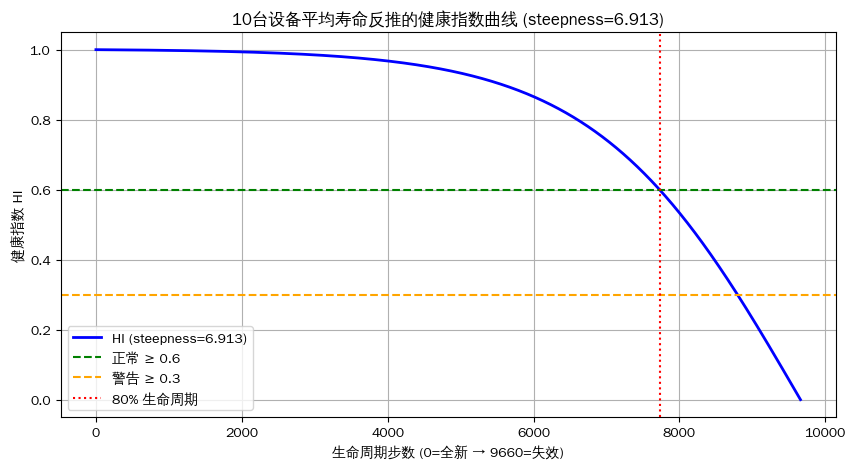

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

# 10台同类设备的life
lifetimes = [9200, 10500, 8500, 9800, 11000, 8700, 9500, 10200, 9300, 9900]
avg_life = round(np.mean(lifetimes))

# np.mean(lifetimes)          # 9660（你现在的 avg_life）
# np.percentile(lifetimes, 20) # 9100
# np.median(lifetimes)        # 9650（几乎和均值一样）
# np.min(lifetimes)           # 8500（最差那台）
# 真实情况下，用mean或者medium都合理，但是重点不在这里，唯一需要改动的就是target_percent，即在达到生命的百分比时预警
# 如果要是同类设备同类工况下导致的lifetimes差距比较大，那这套方法也不合适

print(f"10台设备平均寿命: {avg_life} 步  → 建议 total_life = {avg_life}")
# ==================== 精确反推 steepness
target_percent = 80          # 这里最关键！想在平均寿命的 80% 时进入警告
warning_threshold = 0.6      # 保持 0.6
anomaly_threshold = 0.3      # 可选：你也可以同时算 0.3 的点

target = target_percent / 100.0
label_target = 1 - target

def func(k):
    if k <= 0:
        return 1.0
    s_max = 1 / (1 + np.exp(-k * 1.0))
    s_target = 1 / (1 + np.exp(-k * label_target))
    denom = s_max - 0.5
    if denom <= 1e-12:
        return 1.0
    hi = (s_target - 0.5) / denom          # 精确匹配你 min-max 归一化
    return hi - warning_threshold
sol = root_scalar(func, bracket=[0.1, 50], method='brentq')
steepness = round(sol.root, 3)
print(f"✅ 推荐 steepness = {steepness}  （在 {target_percent}% 时，HI 正好 = {warning_threshold}）")
print(f"求解是否收敛: {sol.converged}")

# ==================== 生成 HI 曲线
total_life = avg_life
print("here--->", total_life)
label = np.linspace(1, 0, total_life)
s_raw = 1 / (1 + np.exp(-steepness * label))
hi = (s_raw - s_raw.min()) / (s_raw.max() - s_raw.min())   

# 验证
idx = int(target_percent / 100 * total_life)
print(f"验证：在第 {idx} 步（{target_percent}%），HI = {hi[idx]:.4f}（完美=0.6）")
# ==================== 画图 ====================
plt.figure(figsize=(10, 5))
plt.plot(hi, color='blue', linewidth=2, label=f'HI (steepness={steepness})')
plt.axhline(y=0.6, color='green', linestyle='--', label='正常 ≥ 0.6')
plt.axhline(y=0.3, color='orange', linestyle='--', label='警告 ≥ 0.3')
plt.axvline(x=idx, color='red', linestyle=':', label=f'{target_percent}% 生命周期')
plt.title(f'10台设备平均寿命反推的健康指数曲线 (steepness={steepness})')
plt.xlabel('生命周期步数 (0=全新 → 9660=失效)')
plt.ylabel('健康指数 HI')
plt.legend()
plt.grid(True)
plt.show()

# 结论
# 基于历史全生命周期，例如上面10台设备，获取平均寿命
# 如果希望在生命达到80%时（target_percent）就进行报警（即留20%时间来进行处理），反推出steepness，从而获得HI退化曲线
# 基于这个HI曲线，来进行监督学习：
# 0.6~1正常（0.6正好达到平均生命周期的80%）
# 0.3~0.6警告
# 0~0.3异常
# 更为重点结论是，只要小于0.6，就表明剩余寿命已经不足20%了

steepness 只和 target_percent 有关，和具体寿命数字（9660 还是 12345）完全无关！

80%时，为6.913
70%时，为4.483


接下来看下phm2012不同设备的HI

In [5]:
import os
phm_dir = './PHM2012/phm-ieee-2012-data-challenge-dataset-master/Learning_set'

bearing_lifetimes = []
for bearing_dir in os.listdir(phm_dir):
    bearing_dir = os.path.join(phm_dir, bearing_dir)
    if os.path.isdir(bearing_dir):
        total_life = len(os.listdir(bearing_dir)) * 10
        bearing_lifetimes.append(total_life)
bearing_lifetimes = np.array(bearing_lifetimes)


avg_life = round(np.mean(bearing_lifetimes))
median_life = round(np.median(bearing_lifetimes))
min_life = bearing_lifetimes.min()
max_life = bearing_lifetimes.max()
cv = (np.std(bearing_lifetimes) / avg_life) * 100   # 变异系数

print(f"PHM2012 Learning_set 共 {len(bearing_lifetimes)} 个轴承")
print(f"寿命统计：平均 {avg_life} 步 | 中位 {median_life} 步")
print(f"范围：{min_life} ~ {max_life} 步")
print(f"寿命变异系数 CV = {cv:.1f}%")



FileNotFoundError: [Errno 2] No such file or directory: './PHM2012/phm-ieee-2012-data-challenge-dataset-master/Learning_set'

+ CV < 15% → 这套纯时间 HI 非常合适，继续用！
+ CV 20%~30% → 还可以用，但建议把 target_percent 调到 75（更保守）
+ CV > 30%（PHM2012 Full_Test_Set 通常是这个情况，因为有 3 种不同工况）→ 之前的总结完全正确：寿命差距太大，单纯用时间比例构造标签就不够准了。
+ 推荐下一步：改用传感器特征驱动的 HI（振动 RMS、峰度、包络谱等），或者对不同工况分别建模。

# 设备健康指数 (HI) 构造与监督学习整体工作流程

1. **寿命分布评估（CV 检查）**  
   - 收集至少 5~10 个完整生命周期数据（n=3 样本太少，CV 计算不稳定）。  
   - 计算 `bearing_lifetimes` 的变异系数 CV = (std / mean) × 100%。  
   - 判断标准：  
     - CV < 15% → 继续使用「时间百分比 HI」方法（非常合适）  
     - 15% ≤ CV ≤ 30% → **可以继续**，但把 `target_percent` 调低到 70~75（更保守预警）  
     - CV > 30% → 这套纯时间方法**不够准确**，建议切换到「传感器特征驱动 HI」（振动 RMS、峰度、包络谱等）或按工况（Condition）分别建模。

2. **基于平均寿命反推 HI 曲线**  
   - 计算 `avg_life = round(np.mean(bearing_lifetimes))`（或中位数）。  
   - **唯一需要调整的参数**：`target_percent`（默认 75~80）。  
     - 想早预警 → 调低到 70~75（steepness 会自动变小，曲线更早下降）  
     - 用 `root_scalar` 精确反推 `steepness`（无需手动写 4.483）。  
   - 生成并画出 HI 曲线（确认在 target_percent% 时 HI 正好 = 0.6）。

3. **生成 HI 伪标签 + 监督学习**  
   - 对**每台轴承**用自己的真实寿命（`group['cycle'].max()`）归一化时间，套同一个 steepness 生成 HI（0~1）。  
   - 可选：再生成三分类标签（正常/警告/异常）。  
   - 用传感器特征训练模型（LightGBM / LSTM / Transformer 回归），目标 = HI（或分类）。  
   - 交叉验证 + 评估（MAE、R²、误报率、漏报率）。

4. **在线预测与报警逻辑**  
   - 模型实时输出预测 HI。  
   - **核心规则**：  
     - HI ≥ 0.6 → 正常（剩余寿命 > 20%）  
     - 0.3 ≤ HI < 0.6 → 警告（剩余寿命不足 20%，建议安排检查）  
     - HI < 0.3 → 异常（立即停机/维护）  
   - **关键结论**：只要预测 HI < 0.6，就表明“当前设备剩余寿命已不足 20%”，必须引起重视。